### importation des bibliotheques

In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OrdinalEncoder

### import du jeu de donnée

In [349]:
data=pd.read_csv("../data/data.csv",sep=";")

### infos general du data set

In [350]:
data.shape

(4424, 37)

In [351]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [352]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [353]:
data.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

 aucune valeur nulle

In [354]:
data[data.duplicated()]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target


variable cible non encodé donc encodons la

In [355]:
mapping=[{'col':'Target',
          'mapping':{
              'Dropout':1,
              'Graduate':2,
              'Enrolled':3
          }
          }]
enc=OrdinalEncoder(mapping=mapping)
Target=enc.fit_transform(data.Target)
data.Target=Target
data.Target

0       1
1       2
2       1
3       2
4       2
       ..
4419    2
4420    1
4421    1
4422    2
4423    2
Name: Target, Length: 4424, dtype: int64

distribution du Target

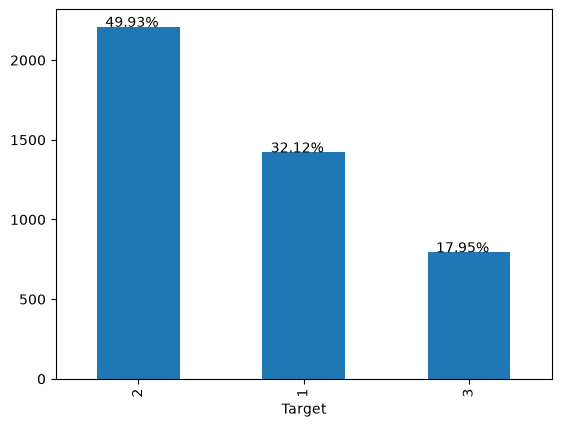

In [356]:
data['Target'].value_counts().plot(kind='bar')
for index,temp in enumerate(data['Target'].value_counts()):
    plt.text(index-0.2,temp,f"{round((temp/data.shape[0])*100,2)}%")

Aucun doublon

In [357]:
numerical=['Previous qualification (grade)','Admission grade','Age at enrollment','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)','Curricular units 1st sem (grade)','Curricular units 1st sem (grade)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (grade)','Curricular units 2nd sem (without evaluations)','Unemployment rate','Inflation rate','GDP']

In [358]:
data[numerical].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (grade),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,10.640822,6.232143,8.063291,10.230206,0.150316,11.566139,1.228029,0.001969
std,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,4.843663,2.195951,3.947951,5.210808,0.753774,2.663850,1.382711,2.269935
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,11.000000,5.000000,6.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,12.285714,6.000000,8.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,13.400000,7.000000,10.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,18.875000,23.000000,33.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [359]:
data['Curricular units 1st sem (grade)']

0        0.000000
1       14.000000
2        0.000000
3       13.428571
4       12.333333
          ...    
4419    13.600000
4420    12.000000
4421    14.912500
4422    13.800000
4423    11.666667
Name: Curricular units 1st sem (grade), Length: 4424, dtype: float64

(array([ 718.,    0.,    0.,    0.,    0.,  548., 1890., 1108.,  147.,
          13.]),
 array([ 0.    ,  1.8875,  3.775 ,  5.6625,  7.55  ,  9.4375, 11.325 ,
        13.2125, 15.1   , 16.9875, 18.875 ]),
 <BarContainer object of 10 artists>)

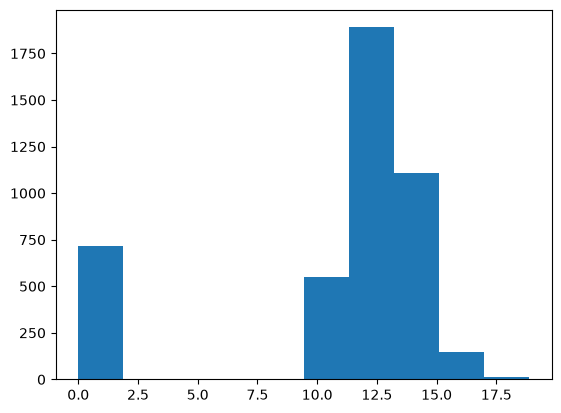

In [360]:
plt.hist(data['Curricular units 1st sem (grade)'])

In [361]:
data.loc[data['Curricular units 1st sem (grade)']<3]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,1
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.0,0,15.5,2.8,-4.06,1
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,6,0,0,0.0,0,12.7,3.7,-1.70,1
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4370,1,1,3,171,1,1,137.0,1,1,3,...,0,0,0,0,0.0,0,12.7,3.7,-1.70,2
4372,1,39,1,9003,1,1,130.0,1,12,12,...,0,6,10,0,0.0,0,12.4,0.5,1.79,1
4375,1,43,1,9991,0,1,161.0,1,37,37,...,0,5,5,0,0.0,0,7.6,2.6,0.32,1
4381,1,1,2,9238,1,1,145.0,1,1,19,...,0,5,11,0,0.0,0,9.4,-0.8,-3.12,3


In [362]:
soupcon=data.loc[data['Curricular units 1st sem (grade)']<3,["Curricular units 1st sem (credited)","Curricular units 1st sem (enrolled)","Curricular units 1st sem (evaluations)","Curricular units 1st sem (approved)","Curricular units 1st sem (grade)","Target"]]
soupcon

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
0,0,0,0,0,0.0,1
2,0,6,0,0,0.0,1
7,0,5,5,0,0.0,1
12,0,6,6,0,0.0,1
20,0,0,0,0,0.0,2
...,...,...,...,...,...,...
4370,0,0,0,0,0.0,2
4372,0,6,7,0,0.0,1
4375,0,5,5,0,0.0,1
4381,0,6,13,0,0.0,3


In [363]:
soupcon['Target'].value_counts()/soupcon.shape[0]

Target
1    0.793872
2    0.107242
3    0.098886
Name: count, dtype: float64

In [364]:
soupcon1=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]==0) & (soupcon["Curricular units 1st sem (evaluations)"]==0)]
soupcon1

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
0,0,0,0,0,0.0,1
20,0,0,0,0,0.0,2
59,0,0,0,0,0.0,3
62,0,0,0,0,0.0,3
66,0,0,0,0,0.0,2
...,...,...,...,...,...,...
4308,0,0,0,0,0.0,1
4331,0,0,0,0,0.0,1
4353,0,0,0,0,0.0,2
4365,0,0,0,0,0.0,2


In [365]:
soupcon1.shape[0]

180

In [366]:
soupcon1["Target"].value_counts()/soupcon1.shape[0]

Target
1    0.427778
2    0.416667
3    0.155556
Name: count, dtype: float64

In [367]:
soupcon2=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]==0) & (soupcon["Curricular units 1st sem (evaluations)"]>0)]
soupcon2

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target


In [368]:
soupcon3=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]>0) & (soupcon["Curricular units 1st sem (evaluations)"]==0)]
soupcon3

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
2,0,6,0,0,0.0,1
36,0,5,0,0,0.0,1
44,0,5,0,0,0.0,1
102,0,6,0,0,0.0,1
104,0,6,0,0,0.0,1
...,...,...,...,...,...,...
4145,0,6,0,0,0.0,1
4181,0,6,0,0,0.0,1
4327,0,5,0,0,0.0,1
4330,0,6,0,0,0.0,1


In [369]:
soupcon3['Target'].value_counts()/soupcon3.shape[0]

Target
1    1.0
Name: count, dtype: float64

In [370]:
soupcon3.shape[0]

169

In [371]:
soupcon4=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]>0) & (soupcon["Curricular units 1st sem (evaluations)"]>0)]
soupcon4

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
7,0,5,5,0,0.0,1
12,0,6,6,0,0.0,1
35,0,7,7,0,0.0,1
56,0,6,10,0,0.0,1
64,0,6,6,0,0.0,3
...,...,...,...,...,...,...
4314,0,5,8,0,0.0,1
4368,0,5,5,0,0.0,1
4372,0,6,7,0,0.0,1
4375,0,5,5,0,0.0,1


In [372]:
soupcon4.shape[0]

369

In [373]:
soupcon4['Target'].value_counts()/soupcon4.shape[0]

Target
1    0.878049
3    0.116531
2    0.005420
Name: count, dtype: float64

In [374]:
soupcon=data.loc[data['Curricular units 1st sem (grade)']>3]
soupcon

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,2
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,2
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,2


(array([231., 582., 950., 888., 632., 296.,  91.,  29.,   4.,   3.]),
 array([ 9.8   , 10.7075, 11.615 , 12.5225, 13.43  , 14.3375, 15.245 ,
        16.1525, 17.06  , 17.9675, 18.875 ]),
 <BarContainer object of 10 artists>)

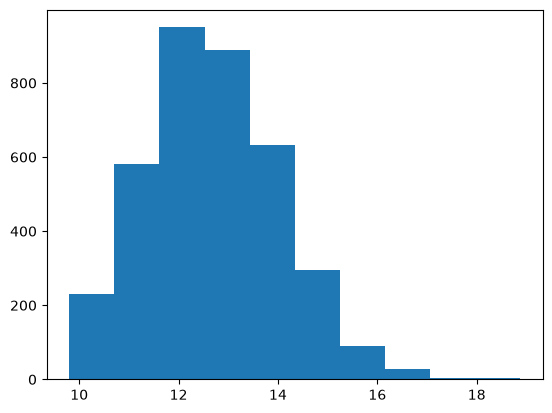

In [375]:
plt.hist(soupcon['Curricular units 1st sem (grade)'])

In [376]:
soupcon['Target'].value_counts()/soupcon.shape[0]

Target
2    0.575283
1    0.229628
3    0.195089
Name: count, dtype: float64

In [377]:
x=np.arange(8,21,2)

for i in range(len(x)-1):
    temp=soupcon[(soupcon["Curricular units 1st sem (grade)"]>=x[i]) & (soupcon["Curricular units 1st sem (grade)"]<x[i+1])]
    print((x[i],x[i+1]))
    print(temp['Target'].value_counts()/temp.shape[0])
    print(temp.shape[0])

temp=soupcon[(soupcon["Curricular units 1st sem (grade)"]>=14) & (soupcon["Curricular units 1st sem (grade)"]<20)]
print((x[i],x[i+1]))
print(temp['Target'].value_counts()/temp.shape[0])
print(temp.shape[0])

(np.int64(8), np.int64(10))
Target
1    1.0
Name: count, dtype: float64
1
(np.int64(10), np.int64(12))
Target
1    0.361137
2    0.358387
3    0.280477
Name: count, dtype: float64
1091
(np.int64(12), np.int64(14))
Target
2    0.629857
1    0.193252
3    0.176892
Name: count, dtype: float64
1956
(np.int64(14), np.int64(16))
Target
2    0.784411
3    0.111111
1    0.104478
Name: count, dtype: float64
603
(np.int64(16), np.int64(18))
Target
2    0.673077
1    0.250000
3    0.076923
Name: count, dtype: float64
52
(np.int64(18), np.int64(20))
Target
1    0.666667
2    0.333333
Name: count, dtype: float64
3
(np.int64(18), np.int64(20))
Target
2    0.773556
1    0.118541
3    0.107903
Name: count, dtype: float64
658


In [378]:
import numpy as np
n = 52
p = 0.673  # Graduate
marge = 1.96 * np.sqrt(p*(1-p)/n)
print(f"{p*100:.0f}% ± {marge*100:.0f}%")

67% ± 13%


conclusion de cette analyse : les etudiants qui ont note_semestre1=0 sont divisés en trois groupes\

1er groupe: matiere_inscrit=0 et n_evaluation=0(47% dropout 41% graduate et 15% enroll) pour faire une conclusion concernant ce groupe on le fera dans les prochains analyses

2eme groupe: matiere_inscrit>0 et n_evaluation=0(dropout 100% ) hypothèse le plus plausible ils ont abandonné avant l'examen

3eme groupe: nb_matiere>0 et n_evaluation>0 (dropout 87%  11% graduate et 0.5% enroll) a verifier car c'est un peu bizarre de ne pas abandonner dans ce cas de figure et de reussir on verifiera dans les prochains analyses


In [379]:
groupe1=data.loc[data['Curricular units 1st sem (grade)']<3,:]
groupe1=groupe1.loc[(groupe1["Curricular units 1st sem (enrolled)"]==0) & (groupe1["Curricular units 1st sem (evaluations)"]==0)]
groupe1

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,1
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,2
59,1,1,3,171,1,1,125.0,1,38,37,...,0,0,0,0,0.0,0,7.6,2.6,0.32,3
62,1,17,3,171,1,1,133.0,1,1,37,...,0,0,0,0,0.0,0,10.8,1.4,1.74,3
66,1,1,3,171,1,1,139.0,1,19,19,...,0,0,0,0,0.0,0,10.8,1.4,1.74,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4308,1,44,1,171,1,39,110.0,1,1,1,...,0,0,0,0,0.0,0,12.4,0.5,1.79,1
4331,1,17,1,171,1,1,145.0,1,37,19,...,0,0,0,0,0.0,0,11.1,0.6,2.02,1
4353,1,1,1,171,1,1,141.0,1,3,1,...,0,0,0,0,0.0,0,12.4,0.5,1.79,2
4365,1,1,2,171,1,1,117.0,1,38,38,...,0,0,0,0,0.0,0,7.6,2.6,0.32,2


In [380]:
groupe1['Course'].value_counts()

Course
171    180
Name: count, dtype: int64

In [381]:
groupe1[['Curricular units 1st sem (approved)',
    'Curricular units 1st sem (credited)']].describe()

,Curricular units 1st sem (approved),Curricular units 1st sem (credited)
count,180.0,180.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [382]:
groupe2=data.loc[data['Curricular units 1st sem (grade)']<3,:]
groupe2=groupe2.loc[(groupe2["Curricular units 1st sem (enrolled)"]>0) & (groupe2["Curricular units 1st sem (evaluations)"]==0)]
groupe2

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,1
36,1,39,1,9119,1,10,133.1,1,34,37,...,0,5,0,0,0.0,0,7.6,2.6,0.32,1
44,1,39,1,9991,0,1,133.1,1,37,37,...,0,5,0,0,0.0,0,16.2,0.3,-0.92,1
102,2,39,1,8014,0,1,130.0,1,37,37,...,0,6,0,0,0.0,0,9.4,-0.8,-3.12,1
104,1,18,1,9853,1,1,123.0,1,19,19,...,0,6,0,0,0.0,0,11.1,0.6,2.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4145,1,1,1,9238,1,1,133.1,1,19,1,...,0,6,0,0,0.0,0,15.5,2.8,-4.06,1
4181,1,43,1,9853,1,1,110.0,1,37,37,...,0,5,10,0,0.0,0,10.8,1.4,1.74,1
4327,2,39,1,9147,1,12,133.1,1,37,37,...,0,5,0,0,0.0,0,9.4,-0.8,-3.12,1
4330,1,1,4,9238,1,1,133.1,1,1,37,...,0,6,0,0,0.0,0,12.7,3.7,-1.70,1


In [383]:
data['Course'].value_counts()

Course
9500    766
9147    380
9238    355
9085    337
9773    331
9991    268
9670    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64

decision prise: creation de trois features:
groupe1: missing_data
groupe2: aggagement
groupe3: low_performance

In [384]:
no_academic_activity= (data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']==0) & (data['Curricular units 1st sem (enrolled)']==0)
data['no_academic_activity']=no_academic_activity.astype(int)

In [385]:
pd.crosstab(
    data['no_academic_activity'],
    data['Target'],
    normalize='index'
) * 100

Target,1,2,3
no_academic_activity,,,
0,31.668238,50.282752,18.049010
1,42.777778,41.666667,15.555556


In [386]:
no_assessment_taken=(data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']==0) & (data['Curricular units 1st sem (enrolled)']>0)
data['no_assessment_taken']=no_assessment_taken.astype(int)


In [387]:
pd.crosstab(
    data['no_assessment_taken'],
    data['Target'],
    normalize='index'
) * 100

Target,1,2,3
no_assessment_taken,,,
0,29.424207,51.915394,18.6604
1,100.000000,0.000000,0.0000


In [388]:
low_performance=(data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']>0) & (data['Curricular units 1st sem (enrolled)']>0)
data['low_performance']=low_performance.astype(int)

In [389]:
pd.crosstab(
    data['no_assessment_taken'],
    data['Target'],
    normalize='index'
)*100

Target,1,2,3
no_assessment_taken,,,
0,29.424207,51.915394,18.6604
1,100.000000,0.000000,0.0000


(array([ 870.,    0.,    0.,    0.,    0.,  442., 1596., 1269.,  234.,
          13.]),
 array([ 0.        ,  1.85714286,  3.71428571,  5.57142857,  7.42857143,
         9.28571429, 11.14285714, 13.        , 14.85714286, 16.71428571,
        18.57142857]),
 <BarContainer object of 10 artists>)

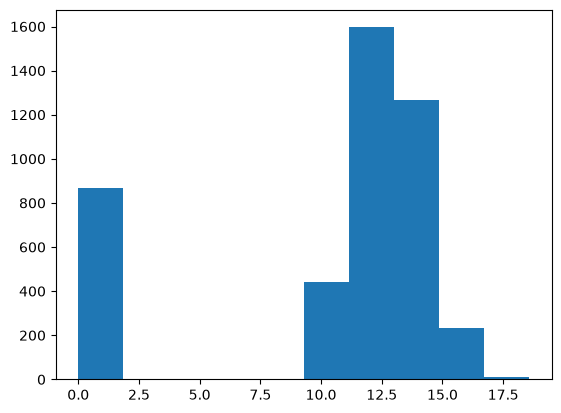

In [390]:
plt.hist(data['Curricular units 2nd sem (grade)'])

In [391]:
null_Second_grade=data.loc[data['Curricular units 2nd sem (grade)']==0,:]

null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']==0,:].shape[0]/null_Second_grade.shape[0]

0.7770114942528735

In [392]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']==0,:].shape[0]/data.loc[data['Curricular units 1st sem (grade)']==0,:].shape[0]

0.9415041782729805

In [393]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']!=0,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance
15,1,1,1,9773,1,1,127.0,1,19,37,...,0,0.0,0,15.5,2.8,-4.06,1,0,0,0
40,1,1,5,9773,1,1,126.0,1,3,3,...,0,0.0,0,12.7,3.7,-1.70,1,0,0,0
89,1,43,2,9119,1,1,115.0,1,38,19,...,0,0.0,0,15.5,2.8,-4.06,3,0,0,0
92,1,15,1,9130,1,1,133.1,41,1,1,...,0,0.0,0,8.9,1.4,3.51,1,0,0,0
93,2,39,1,9853,1,10,133.1,1,37,34,...,0,0.0,1,7.6,2.6,0.32,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4323,1,39,1,9991,0,19,133.1,1,37,37,...,0,0.0,0,12.4,0.5,1.79,1,0,0,0
4346,1,17,2,9254,1,1,107.0,1,12,19,...,0,0.0,0,10.8,1.4,1.74,1,0,0,0
4356,1,39,1,9085,1,19,133.1,1,37,37,...,0,0.0,0,11.1,0.6,2.02,1,0,0,0
4363,1,17,3,9853,1,1,133.1,1,34,34,...,0,0.0,0,7.6,2.6,0.32,1,0,0,0


In [394]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']!=0,'Target'].value_counts()

Target
1    181
3     13
Name: count, dtype: int64

In [395]:
data['grade2_echec']=(data['Curricular units 2nd sem (grade)']==0) & (data['Curricular units 1st sem (grade)']!=0)
data['grade2_echec']=data['grade2_echec'].astype(int)


In [396]:
pd.crosstab(
    data['grade2_echec'],
    data['Target'],
    normalize='index'
)*100

Target,1,2,3
grade2_echec,,,
0,29.314421,52.222222,18.463357
1,93.298969,0.000000,6.701031


(array([ 241.,  490., 1173., 1244.,  705.,  321.,  172.,   56.,   16.,
           6.]),
 array([ 95. , 104.5, 114. , 123.5, 133. , 142.5, 152. , 161.5, 171. ,
        180.5, 190. ]),
 <BarContainer object of 10 artists>)

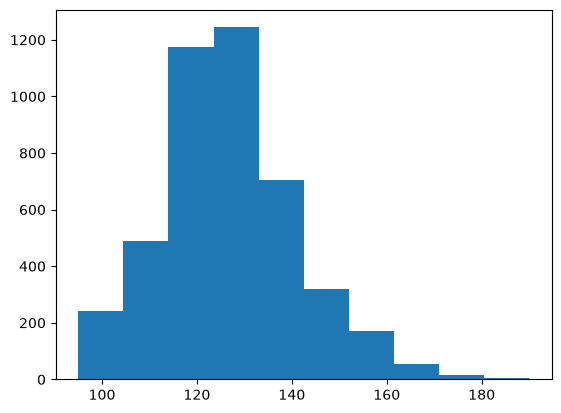

In [397]:
plt.hist(data['Admission grade'])

In [398]:
data.loc[data['Admission grade']<100,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance,grade2_echec
142,1,51,1,9147,1,1,99.0,1,3,1,...,0.000000,0,8.9,1.4,3.51,3,0,0,1,0
228,1,39,2,9670,1,1,140.0,1,34,34,...,0.000000,0,7.6,2.6,0.32,1,0,0,1,0
255,2,39,1,9556,1,19,133.1,1,38,37,...,0.000000,0,8.9,1.4,3.51,1,0,0,0,1
399,1,17,1,9147,1,1,96.0,1,38,37,...,0.000000,3,16.2,0.3,-0.92,1,0,0,0,1
417,1,1,1,9853,1,1,133.1,1,19,19,...,11.000000,0,12.7,3.7,-1.70,1,0,0,0,0
554,1,17,2,9147,1,1,133.1,1,1,1,...,0.000000,0,11.1,0.6,2.02,1,0,0,1,0
709,1,39,1,8014,0,1,133.1,1,37,11,...,0.000000,0,12.4,0.5,1.79,1,0,0,1,0
867,1,39,1,9119,1,19,133.1,1,37,38,...,0.000000,0,12.4,0.5,1.79,1,0,0,1,0
921,1,39,1,8014,0,1,133.1,1,37,37,...,11.500000,0,10.8,1.4,1.74,2,0,0,0,0
1163,4,39,1,8014,0,1,160.0,1,37,37,...,11.333333,0,15.5,2.8,-4.06,2,0,0,0,0


(array([  96.,  194.,  748., 1062., 1532.,  493.,  204.,   68.,   22.,
           5.]),
 array([ 95. , 104.5, 114. , 123.5, 133. , 142.5, 152. , 161.5, 171. ,
        180.5, 190. ]),
 <BarContainer object of 10 artists>)

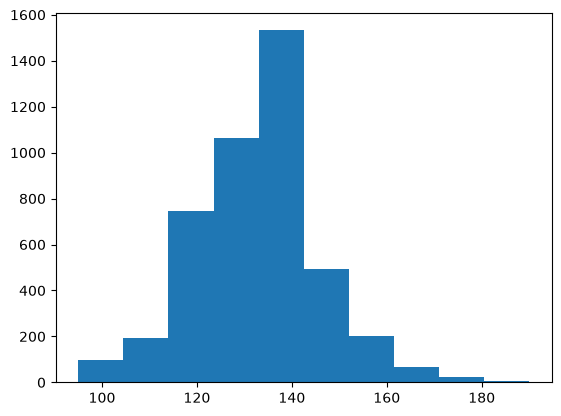

In [399]:
plt.hist(data['Previous qualification (grade)'])